In [47]:
import pandas as pd 
import json 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [48]:
baseline = pd.read_json('../localgpt/loss_tracker/baseline.json')
glu = pd.read_json('../localgpt/loss_tracker/glu.json')
rmsnorm = pd.read_json('../localgpt/loss_tracker/rmsnorm.json')
rope = pd.read_json('../localgpt/loss_tracker/rope.json')

In [49]:
rope.head(5)

,step,train,test
0,0,11.021471,11.022122
1,100,3.947241,3.939496
2,200,3.467940,3.468258
3,300,3.234106,3.236456
4,400,3.080016,3.077531


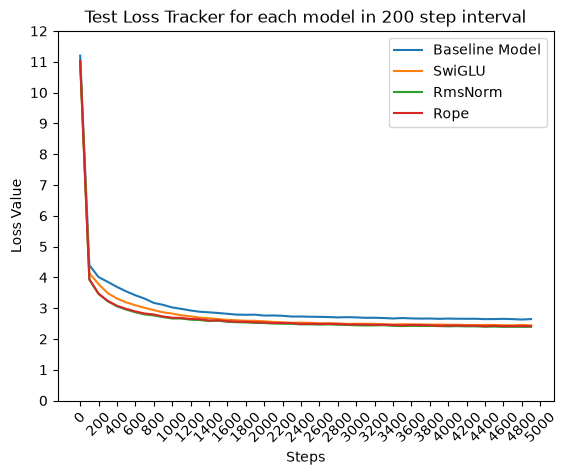

In [50]:
sns.lineplot(x = 'step', y = 'test', data = baseline, label = 'Baseline Model')
sns.lineplot(x = 'step', y = 'test', data = glu, label = 'SwiGLU')
sns.lineplot(x = 'step', y = 'test', data = rmsnorm, label = 'RmsNorm')
sns.lineplot(x = 'step', y = 'test', data = rope, label = 'Rope')
plt.xticks(np.arange(0,5001, 200), rotation = 45)
plt.yticks(np.arange(0,13,1))
plt.ylabel('Loss Value')
plt.xlabel('Steps')
plt.title('Test Loss Tracker for each model in 200 step interval')
plt.legend()
plt.show()

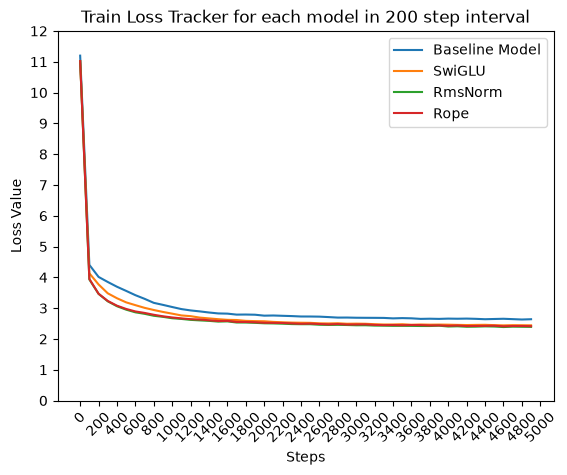

In [51]:
sns.lineplot(x = 'step', y = 'train', data = baseline, label = 'Baseline Model')
sns.lineplot(x = 'step', y = 'train', data = glu, label = 'SwiGLU')
sns.lineplot(x = 'step', y = 'train', data = rmsnorm, label = 'RmsNorm')
sns.lineplot(x = 'step', y = 'train', data = rope, label = 'Rope')
plt.xticks(np.arange(0,5001, 200), rotation = 45)
plt.yticks(np.arange(0,13,1))
plt.ylabel('Loss Value')
plt.xlabel('Steps')
plt.title('Train Loss Tracker for each model in 200 step interval')
plt.legend()
plt.show()

In [52]:
### Difference between the models 
model_difference = pd.DataFrame()
model_difference['steps'] = baseline['step']
model_difference['baseline_train'] = baseline['train']
model_difference['baseline_test'] = baseline['test']
model_difference['test_rmsnorm_baseline'] = rmsnorm['test'] - baseline['test']
model_difference['test_rope_baseline'] = rope['test'] - baseline['test']
model_difference['test_glu_baseline'] = glu['test'] - baseline['test']
model_difference['train_rmsnorm_baseline'] = rmsnorm['train'] - baseline['train']
model_difference['train_rope_baseline'] = rope['train'] - baseline['train']
model_difference['train_glu_baseline'] = glu['train'] - baseline['train']
model_difference.head(5)

,steps,baseline_train,baseline_test,test_rmsnorm_baseline,test_rope_baseline,test_glu_baseline,train_rmsnorm_baseline,train_rope_baseline,train_glu_baseline
0,0,11.198402,11.199704,-0.178029,-0.177582,-0.176100,-0.177472,-0.176931,-0.174379
1,100,4.405084,4.394290,-0.471978,-0.454794,-0.256646,-0.473176,-0.457843,-0.272726
2,200,4.014450,4.008520,-0.544256,-0.540262,-0.229271,-0.549294,-0.546510,-0.244339
3,300,3.849838,3.853045,-0.628395,-0.616589,-0.366012,-0.627883,-0.615733,-0.367630
4,400,3.695111,3.689395,-0.629436,-0.611864,-0.377209,-0.632201,-0.615095,-0.373123


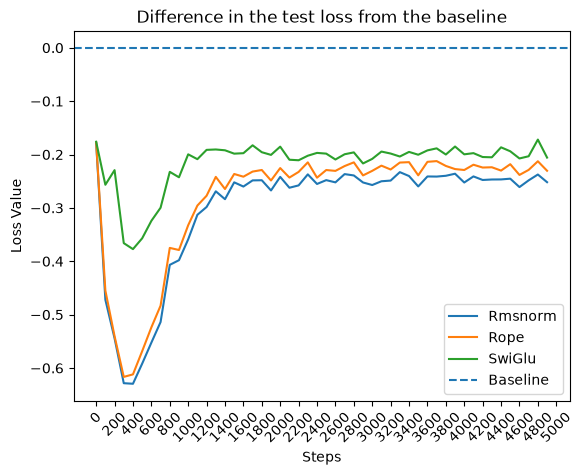

In [53]:
### Plotting the difference from the baseline
sns.lineplot(x = 'steps', y = 'test_rmsnorm_baseline', data = model_difference, label = 'Rmsnorm')
sns.lineplot(x = 'steps', y = 'test_rope_baseline', data = model_difference, label = 'Rope')
sns.lineplot(x = 'steps', y = 'test_glu_baseline', data = model_difference, label = 'SwiGlu')
plt.axhline(y=0, linestyle='--', label='Baseline')
plt.xticks(np.arange(0,5001, 200), rotation = 45)
plt.ylabel('Loss Value')
plt.xlabel('Steps')
plt.title('Difference in the test loss from the baseline')
plt.legend()
plt.show()

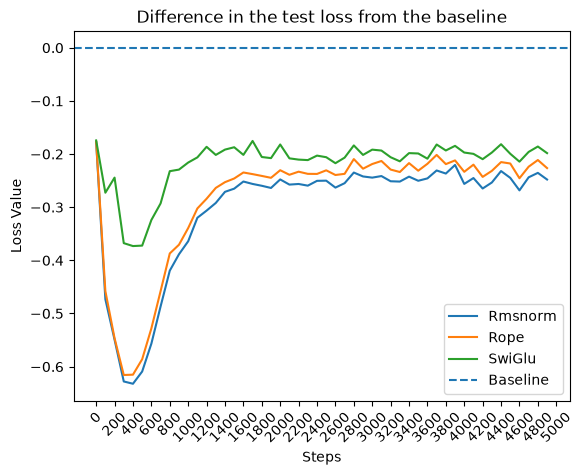

In [54]:
sns.lineplot(x = 'steps', y = 'train_rmsnorm_baseline', data = model_difference, label = 'Rmsnorm')
sns.lineplot(x = 'steps', y = 'train_rope_baseline', data = model_difference, label = 'Rope')
sns.lineplot(x = 'steps', y = 'train_glu_baseline', data = model_difference, label = 'SwiGlu')
plt.axhline(y=0, linestyle='--', label='Baseline')
plt.xticks(np.arange(0,5001, 200), rotation = 45)
plt.ylabel('Loss Value')
plt.xlabel('Steps')
plt.title('Difference in the test loss from the baseline')
plt.legend()
plt.show()